# Ejercicio Python 2: Simulación de inversión periódica (Dollar Cost Averaging)
Aplicar simulaciones para comparar dos estrategias de inversión: aportaciones periódicas frente a inversión única inicial.

Selecciona un activo financiero y descarga precios históricos de al menos 3 años.

Define dos estrategias de inversión con un monto total de $5,000:

Inversión única: se invierte todo el monto al inicio del periodo.

Inversión periódica (DCA): se invierten $100 cada semana hasta completar $5,000.

Simula 10,000 trayectorias de precios futuros usando Monte Carlo (con medias y desviaciones obtenidas de los datos).

Calcula y compara para ambas estrategias:

Valor final promedio de la inversión.

Desviación estándar del valor final.

Probabilidad de que el valor final sea menor al capital invertido.

Construye gráficos:

Histogramas comparativos de los valores finales.

Evolución promedio de la inversión bajo ambas estrategias.

Redacta un análisis breve, usando markdown en tu notebook, respondiendo:

¿En qué condiciones es más ventajosa la inversión periódica?

¿Cuándo es preferible la inversión en un solo momento?

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ticker = 'MSFT'
prices = yf.download(tickers=ticker, start='2023-01-01', end='2026-01-01')['Close']
returns = prices.pct_change().dropna()
mu = returns.mean()
sigma = returns.std()

C:\Users\j_ale\AppData\Local\Temp\ipykernel_25388\1583070286.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers=ticker, start='2023-01-01', end='2026-01-01')['Close']
[*********************100%***********************]  1 of 1 completed


                   Métrica  Estrategia A  Estrategia B
      Valor Final Promedio    6546.45858   5755.580913
       Desviación Estándar    1545.60150    812.069760
Prob. de pérdida (< $5000)       0.14830      0.179200


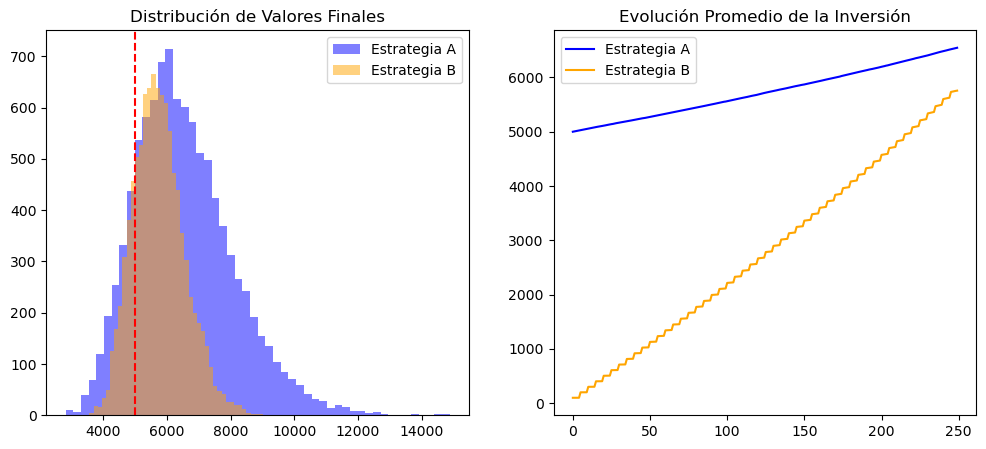

In [3]:
capital_total = 5000
monto_semanal = 100
n_simulaciones = 10000
semanas_totales = int(capital_total / monto_semanal) 
dias_simulacion = semanas_totales * 5 

rendimientos_sim = np.random.normal(mu, sigma, (dias_simulacion, n_simulaciones))
precios_sim = prices.iloc[-1].item() * (1 + rendimientos_sim).cumprod(axis=0)

resultados_A = []
resultados_B = []

for s in range(n_simulaciones):
    precios_trayectoria = precios_sim[:, s]
    precio_inicial = precios_trayectoria[0]
    precio_final = precios_trayectoria[-1]
    
    acciones_A = capital_total / precio_inicial
    valor_final_A = acciones_A * precio_final
    resultados_A.append(valor_final_A)
    
    acciones_B = 0
    for i in range(0, dias_simulacion, 5):
        precio_compra = precios_trayectoria[i]
        acciones_B += monto_semanal / precio_compra
    
    valor_final_B = acciones_B * precio_final
    resultados_B.append(valor_final_B)

res_A = np.array(resultados_A)
res_B = np.array(resultados_B)

stats = pd.DataFrame({
    'Métrica': ['Valor Final Promedio', 'Desviación Estándar', 'Prob. de pérdida (< $5000)'],
    'Estrategia A': [res_A.mean(), res_A.std(), (res_A < capital_total).mean()],
    'Estrategia B': [res_B.mean(), res_B.std(), (res_B < capital_total).mean()]
})
print(stats.to_string(index=False))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(res_A, bins=50, alpha=0.5, label='Estrategia A', color='blue')
plt.hist(res_B, bins=50, alpha=0.5, label='Estrategia B', color='orange')
plt.axvline(capital_total, color='red', linestyle='--')
plt.title('Distribución de Valores Finales')
plt.legend()

plt.subplot(1, 2, 2)
evolucion_A_media = (capital_total / precios_sim[0, :].mean()) * precios_sim.mean(axis=1)
evolucion_B_acum = np.zeros(dias_simulacion)
acc_prom_B = 0
for i in range(dias_simulacion):
    if i % 5 == 0 and i/5 < semanas_totales:
        acc_prom_B += monto_semanal / precios_sim[i, :].mean()
    evolucion_B_acum[i] = acc_prom_B * precios_sim[i, :].mean()

plt.plot(evolucion_A_media, label='Estrategia A', color='blue')
plt.plot(evolucion_B_acum, label='Estrategia B', color='orange')
plt.title('Evolución Promedio de la Inversión')
plt.legend()
plt.show()

Redacta un análisis breve, usando markdown en tu notebook, respondiendo:

¿En qué condiciones es más ventajosa la inversión periódica?
- Parece ser más ventajosa una inversión periódica cuando estás considerando la volatilidad, ya que la estrategia B resultó tener una mucho menor volatilidad, por lo que asumo que en casos donde el mercado se encuentra con alta volatilidad, es mejor hacer una inversión periódica, en caso de que los precios caigan, podemos comprar más barato en comparación con comprar todo de una y al mismo tiempo nos protegemos de caídas grandes.

¿Cuándo es preferible la inversión en un solo momento?
- Por el otro lado, nuestra inversión en un solo momento nos trajo un mayor rendimiento a costo de una mayor volatilidad, por lo que pienso que, si el activo tiene una tendencia de crecimiento clara y sostenida, es mejor poner a trabajar todo el dinero desde el principio para aprovechar el rendimiento acumulado el mayor tiempo posible, en lugar de esperar y comprar a precios cada vez más altos.